# CardioIA — Fase 2  
## Parte 2: Classificador básico de texto para triagem de risco

Este notebook implementa uma simulação acadêmica de triagem clínica usando:

- **TF-IDF** para transformar frases em vetores numéricos;
- **Regressão Logística** para classificar as frases em `alto risco` ou `baixo risco`;
- avaliação com **acurácia, precision, recall, F1-score e matriz de confusão**;
- uma seção de **análise de viés e limitações**.

> **Aviso:** este projeto é exclusivamente educacional. Ele não é um dispositivo médico e não deve ser usado para diagnóstico ou decisão clínica real.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

BASE = Path.cwd()
dados = pd.read_csv(BASE / "dataset_risco.csv")
dados.head()


,frase,situacao
0,Sinto uma dor forte no peito e muita falta de ...,alto risco
1,Estou com aperto intenso no peito e suor frio ...,alto risco
2,Tive dor no peito que irradiou para o braço es...,alto risco
3,Meu coração está muito acelerado e estou com t...,alto risco
4,Desmaiei hoje depois de sentir palpitações for...,alto risco


## 1. Inspeção do dataset

Quantidade de registros: 80

Distribuição das classes:
situacao
alto risco     40
baixo risco    40
Name: count, dtype: int64


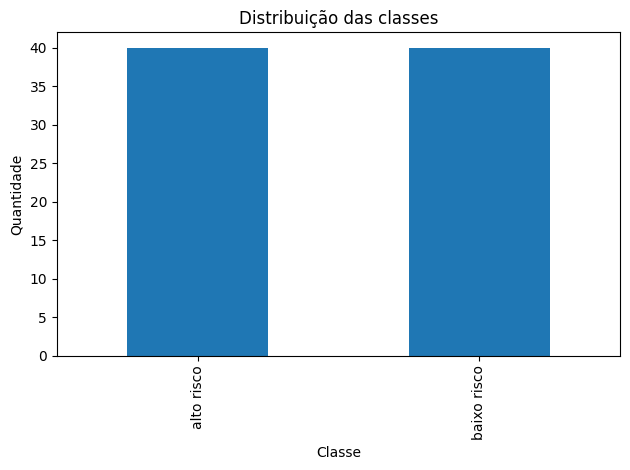

In [2]:
print("Quantidade de registros:", len(dados))
print("\nDistribuição das classes:")
print(dados["situacao"].value_counts())

ax = dados["situacao"].value_counts().plot(kind="bar", title="Distribuição das classes")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade")
plt.tight_layout()
plt.savefig(BASE / "outputs" / "distribuicao_classes.png", dpi=160)
plt.show()


## 2. Separação treino/teste

Usamos divisão estratificada para manter a proporção das duas classes no conjunto de treino e teste.


In [3]:
X = dados["frase"]
y = dados["situacao"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=1,
    stratify=y
)

print("Treino:", len(X_treino))
print("Teste:", len(X_teste))


Treino: 60
Teste: 20


## 3. TF-IDF + Regressão Logística

O `TfidfVectorizer` converte palavras e combinações de duas palavras em pesos numéricos.  
A Regressão Logística aprende quais padrões estão mais associados a cada classe.


In [4]:
modelo = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 2),
        sublinear_tf=True
    )),
    ("classificador", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

modelo.fit(X_treino, y_treino)
print("Modelo treinado com sucesso.")


Modelo treinado com sucesso.


## 4. Avaliação

In [5]:
predicoes = modelo.predict(X_teste)
acuracia = accuracy_score(y_teste, predicoes)

print(f"Acurácia no conjunto de teste: {acuracia:.2%}\n")
print("Relatório de classificação:")
print(classification_report(y_teste, predicoes))


Acurácia no conjunto de teste: 90.00%

Relatório de classificação:
              precision    recall  f1-score   support

  alto risco       0.83      1.00      0.91        10
 baixo risco       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20



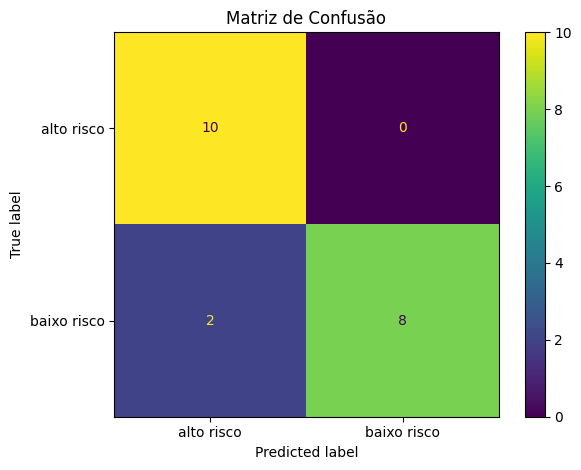

In [6]:
rotulos = ["alto risco", "baixo risco"]
cm = confusion_matrix(y_teste, predicoes, labels=rotulos)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rotulos)
disp.plot(values_format="d")
plt.title("Matriz de Confusão")
plt.tight_layout()
plt.savefig(BASE / "outputs" / "matriz_confusao.png", dpi=160)
plt.show()


### Validação cruzada

Como a base é pequena e simulada, uma única divisão treino/teste pode variar bastante.  
Por isso, também calculamos a média de acurácia em 5 divisões.


In [7]:
scores = cross_val_score(modelo, X, y, cv=5, scoring="accuracy")
print("Acurácias por fold:", [round(s, 3) for s in scores])
print(f"Média da validação cruzada: {scores.mean():.2%}")


Acurácias por fold: [np.float64(1.0), np.float64(1.0), np.float64(0.938), np.float64(0.938), np.float64(1.0)]
Média da validação cruzada: 97.50%


## 5. Teste com novas frases

In [8]:
frases_novas = [
    "Estou com dor forte no peito, suor frio e muita falta de ar.",
    "Senti uma pontada leve no peito depois da academia e já passou.",
    "Meu coração disparou e quase desmaiei.",
    "Estou cansado depois de dormir pouco, mas sem dor no peito."
]

for frase in frases_novas:
    classe = modelo.predict([frase])[0]
    probabilidades = modelo.predict_proba([frase])[0]
    classes = modelo.classes_
    confianca = dict(zip(classes, probabilidades))[classe]
    print(f"Frase: {frase}")
    print(f"Classificação: {classe} | confiança do modelo: {confianca:.1%}\n")


Frase: Estou com dor forte no peito, suor frio e muita falta de ar.
Classificação: alto risco | confiança do modelo: 72.8%

Frase: Senti uma pontada leve no peito depois da academia e já passou.
Classificação: baixo risco | confiança do modelo: 60.5%

Frase: Meu coração disparou e quase desmaiei.
Classificação: alto risco | confiança do modelo: 56.2%

Frase: Estou cansado depois de dormir pouco, mas sem dor no peito.
Classificação: baixo risco | confiança do modelo: 56.4%



## 6. Análise de viés, governança e limitações

A base foi construída de forma **simulada e balanceada** (mesma quantidade de exemplos de alto e baixo risco), o que reduz um viés simples de desbalanceamento de classes. Mesmo assim:

1. **Viés de representação:** as frases foram criadas manualmente e não representam toda a diversidade de pacientes, vocabulários, idades, regiões ou condições clínicas.
2. **Viés de vocabulário:** o modelo pode associar palavras muito específicas, como “suor frio” ou “desmaio”, à classe de alto risco e falhar quando o mesmo quadro é descrito de outra maneira.
3. **Generalização limitada:** bons resultados em uma base sintética pequena não comprovam desempenho em dados reais.
4. **Fairness:** como a base não contém atributos demográficos, não é possível medir diferenças de desempenho entre grupos. Em um projeto real, seria necessário avaliar métricas por subgrupos de forma ética e protegendo a privacidade.
5. **Uso responsável:** um classificador desse tipo deve ser apenas um apoio de triagem. Diagnóstico e conduta precisam de profissionais habilitados, validação clínica e governança adequada.

Essas limitações são importantes porque uma alta acurácia em dados simulados pode gerar uma falsa sensação de segurança.


## Conclusão

O experimento demonstra o fluxo completo pedido na atividade:

**texto → TF-IDF → modelo de classificação → previsão → avaliação → análise crítica de vieses**

A solução é simples, reproduzível e adequada como protótipo acadêmico do CardioIA.
